# Projet: Etude de marché sur l'alimentation et la sous-nutrition mondiale

## Objectifs:
- Mesurer la production alimentaire mondiale
- Analyser sa répartition entre les individus
- Identifier les pays les plus en difficulté, qui cumulent sous-nutrition et forte dépendance à l'aide alimentaire

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.1 - Importation des librairies</h3>
</div>

In [ ]:
#Importation de la librairie Pandas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.2 - Chargement des fichiers Excel</h3>
</div>

In [ ]:
#Importation du fichier population.csv
population = pd.read_csv('data/population.csv')

#Importation du fichier dispo_alimentaire.csv
dispo_alimentaire = pd.read_csv('data/dispo_alimentaire.csv')

#Importation du fichier aide_alimentaire.csv
aide_alimentaire = pd.read_csv('data/aide_alimentaire.csv')

#Importation du fichier sous_nutrition.csv
sous_nutrition = pd.read_csv('data/sous_nutrition.csv')


<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.1 - Analyse exploratoire du fichier population</h3>
</div>

In [ ]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(population.shape[0]))
print("Le tableau comporte {} colonne(s)".format(population.shape[1]))

Le tableau comporte 1416 observation(s) ou article(s)
Le tableau comporte 3 colonne(s)


In [ ]:
#Consulter le nombre de colonnes
population.shape[1]
#La nature des données dans chacune des colonnes
population.info()
#Le nombre de valeurs présentes dans chacune des colonnes
population.count()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1416 entries, 0 to 1415
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Zone    1416 non-null   object 
 1   Année   1416 non-null   int64  
 2   Valeur  1416 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 33.3+ KB


,0
Zone,1416
Année,1416
Valeur,1416


In [ ]:
#Affichage les 5 premières lignes de la table
population.head(5)

,Zone,Année,Valeur
0,Afghanistan,2013,32269.589
1,Afghanistan,2014,33370.794
2,Afghanistan,2015,34413.603
3,Afghanistan,2016,35383.032
4,Afghanistan,2017,36296.113


In [ ]:
#Nous allons harmoniser les unités. Pour cela, nous avons décidé de multiplier la population par 1000
#Multiplication de la colonne valeur par 1000
population['Valeur'] = population['Valeur'] * 1000

In [ ]:
#changement du nom de la colonne Valeur par Population
population.rename(columns = {'Valeur' : 'Population'}, inplace=True)

In [ ]:
#Affichage les 5 premières lignes de la table pour voir les modifications
population.head(5)

,Zone,Année,Population
0,Afghanistan,2013,32269589.0
1,Afghanistan,2014,33370794.0
2,Afghanistan,2015,34413603.0
3,Afghanistan,2016,35383032.0
4,Afghanistan,2017,36296113.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.2 - Analyse exploratoire du fichier disponibilité alimentaire</h3>
</div>

In [ ]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(dispo_alimentaire.shape[0]))
print("Le tableau comporte {} colonne(s)".format(dispo_alimentaire.shape[1]))

Le tableau comporte 15605 observation(s) ou article(s)
Le tableau comporte 18 colonne(s)


In [ ]:
#Consulter le nombre de colonnes
dispo_alimentaire.shape[1]

18

In [ ]:
#Affichage les 5 premières lignes de la table
dispo_alimentaire.head(5)

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,NaN,NaN,5.0,1.72,0.20,0.77,53.0,NaN,NaN,53.0,NaN,53.0,NaN,NaN,NaN
1,Afghanistan,"Agrumes, Autres",vegetale,NaN,NaN,1.0,1.29,0.01,0.02,41.0,2.0,40.0,39.0,2.0,3.0,NaN,NaN,NaN
2,Afghanistan,Aliments pour enfants,vegetale,NaN,NaN,1.0,0.06,0.01,0.03,2.0,NaN,2.0,2.0,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,Ananas,vegetale,NaN,NaN,0.0,0.00,NaN,NaN,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,Bananes,vegetale,NaN,NaN,4.0,2.70,0.02,0.05,82.0,NaN,82.0,82.0,NaN,NaN,NaN,NaN,NaN


In [ ]:
#remplacement des NaN dans le dataset par des 0
dispo_alimentaire.fillna(0, inplace=True)

In [ ]:
#multiplication de toutes les lignes contenant des milliers de tonnes en Kg
dispo_alimentaire.loc[:, 'Disponibilité intérieure': 'Variation de stock'] = dispo_alimentaire.loc[:, 'Disponibilité intérieure': 'Variation de stock']*1000000
dispo_alimentaire.loc[:, 'Aliments pour animaux':'Autres Utilisations'] = dispo_alimentaire.loc[:, 'Aliments pour animaux':'Autres Utilisations'] * 1000000

In [ ]:
# Remplacement de la colonne Nourriture par Aliments pour humains
dispo_alimentaire.rename(columns={'Nourriture':'Aliments pour humains'}, inplace=True)

In [ ]:
#Affichage les 5 premières lignes de la table
dispo_alimentaire.head(5)

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Aliments pour humains,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53000000.0,0.0,0.0,53000000.0,0.0,53000000.0,0.0,0.0,0.0
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41000000.0,2000000.0,40000000.0,39000000.0,2000000.0,3000000.0,0.0,0.0,0.0
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2000000.0,0.0,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82000000.0,0.0,82000000.0,82000000.0,0.0,0.0,0.0,0.0,0.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.3 - Analyse exploratoire du fichier aide alimentaire</h3>
</div>

In [ ]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(aide_alimentaire.shape[0]))
print("Le tableau comporte {} colonne(s)".format(aide_alimentaire.shape[1]))

Le tableau comporte 1475 observation(s) ou article(s)
Le tableau comporte 4 colonne(s)


In [ ]:
#Consulter le nombre de colonnes
aide_alimentaire.shape[1]

4

In [ ]:
#Affichage les 5 premières lignes de la table
aide_alimentaire.head(5)

,Pays bénéficiaire,Année,Produit,Valeur
0,Afghanistan,2013,Autres non-céréales,682
1,Afghanistan,2014,Autres non-céréales,335
2,Afghanistan,2013,Blé et Farin,39224
3,Afghanistan,2014,Blé et Farin,15160
4,Afghanistan,2013,Céréales,40504


In [ ]:
#changement du nom de la colonne Pays bénéficiaire par Zone
aide_alimentaire.rename(columns={'Pays bénéficiaire' : 'Zone'}, inplace=True)

In [ ]:
#Multiplication de la colonne Aide_alimentaire qui contient des tonnes par 1000 pour avoir des kg
aide_alimentaire['Valeur'] = aide_alimentaire['Valeur'] * 1000
aide_alimentaire.rename(columns={'Valeur':'Aide_alimentaire'}, inplace=True)

In [ ]:
#Affichage les 5 premières lignes de la table
aide_alimentaire.head(5)

,Zone,Année,Produit,Aide_alimentaire
0,Afghanistan,2013,Autres non-céréales,682000
1,Afghanistan,2014,Autres non-céréales,335000
2,Afghanistan,2013,Blé et Farin,39224000
3,Afghanistan,2014,Blé et Farin,15160000
4,Afghanistan,2013,Céréales,40504000


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.3 - Analyse exploratoire du fichier sous nutrition</h3>
</div>

In [ ]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(sous_nutrition.shape[0]))
print("Le tableau comporte {} colonne(s)".format(sous_nutrition.shape[1]))

Le tableau comporte 1218 observation(s) ou article(s)
Le tableau comporte 3 colonne(s)


In [ ]:
#Consulter le nombre de colonnes
sous_nutrition.shape[1]

3

In [ ]:
#Afficher les 5 premières lignes de la table
sous_nutrition.head(5)

,Zone,Année,Valeur
0,Afghanistan,2012-2014,8.6
1,Afghanistan,2013-2015,8.8
2,Afghanistan,2014-2016,8.9
3,Afghanistan,2015-2017,9.7
4,Afghanistan,2016-2018,10.5


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.1 - Proportion de personnes en sous nutrition</h3>
</div>

In [ ]:
#changement du nom de la colonne Valeur par sous_nutrition
sous_nutrition.rename(columns = {'Valeur' : 'Sous_nutrition'}, inplace=True)

In [ ]:
#Conversion de la colonne sous nutrition en numérique
sous_nutrition['Sous_nutrition'] = pd.to_numeric(sous_nutrition['Sous_nutrition'], errors='coerce')

In [ ]:
#Conversion de la colonne (avec l'argument errors=coerce qui permet de convertir automatiquement les lignes qui ne sont pas des nombres en NaN)
#Puis remplacement des NaN en 0
sous_nutrition.fillna(0, inplace=True)

In [ ]:
#Multiplication de la colonne sous_nutrition par 1000000
sous_nutrition['Sous_nutrition'] = sous_nutrition['Sous_nutrition'] * 1000000

In [ ]:
#Afficher les 5 premières lignes de la table
sous_nutrition.head(5)

,Zone,Année,Sous_nutrition
0,Afghanistan,2012-2014,8600000.0
1,Afghanistan,2013-2015,8800000.0
2,Afghanistan,2014-2016,8900000.0
3,Afghanistan,2015-2017,9700000.0
4,Afghanistan,2016-2018,10500000.0


In [ ]:
# Rajouter une colonne Année median dans la table Sous-nutrition
years_median = []
for year in sous_nutrition['Année']:
    start_year, end_year = map(int, year.split('-'))
    years_median.append((end_year+start_year)/2)
sous_nutrition['Année médian'] = years_median
sous_nutrition['Année médian'] = sous_nutrition['Année médian'].astype(int)

In [ ]:
# Jointure entre le stables population et sous_nutrition
population_sous_nutrition_merge = pd.merge(population, sous_nutrition, on='Zone', suffixes=('_population', '_sous_nutrition'))
population_sous_nutrition_2017 = population_sous_nutrition_merge.loc[
    (population_sous_nutrition_merge['Année_population'] == 2017) &
    (population_sous_nutrition_merge['Année médian']==2017)
    ]

In [ ]:
#Affichage du dataset
population_sous_nutrition_2017.head()

,Zone,Année_population,Population,Année_sous_nutrition,Sous_nutrition,Année médian
28,Afghanistan,2017,36296113.0,2016-2018,10500000.0,2017
64,Afrique du Sud,2017,57009756.0,2016-2018,3100000.0,2017
100,Albanie,2017,2884169.0,2016-2018,100000.0,2017
136,Algérie,2017,41389189.0,2016-2018,1300000.0,2017
172,Allemagne,2017,82658409.0,2016-2018,0.0,2017


In [ ]:
# Calcul et affichage du nombre de personnes en état de sous-nutrition au niveau mondial
sous_nutrition_mondiale = population_sous_nutrition_2017['Sous_nutrition'].sum()
ratio_sous_nutrition_mondiale = sous_nutrition_mondiale / population_sous_nutrition_2017['Population'].sum()

print("Nombre de personnes en sous-nutrition en 2017 au niveau mondial : {} ".format(sous_nutrition_mondiale))
print("Ratio personnes en sous-nutrition en 2017 au niveau mondial : {}%".format(round(ratio_sous_nutrition_mondiale*100, 2)))

Nombre de personnes en sous-nutrition en 2017 au niveau mondial : 535700000.0 
Ratio personnes en sous-nutrition en 2017 au niveau mondial : 7.1%


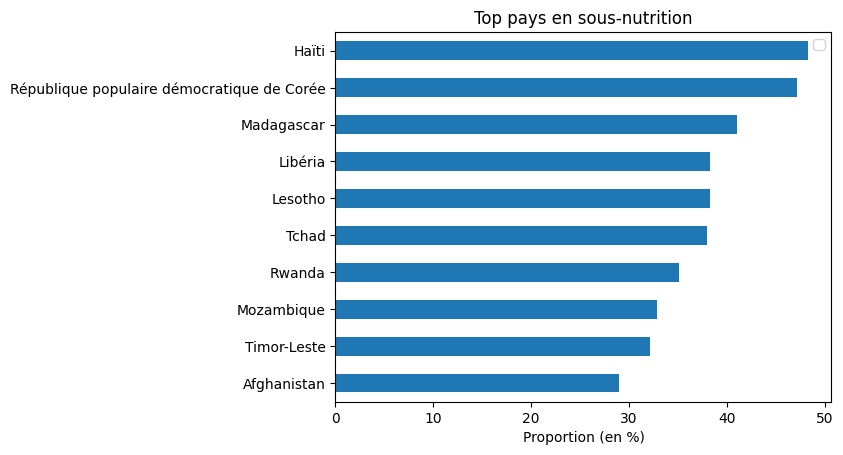

,Zone,Proportion_pays_sous_nutri(%)
72,Haïti,48.26
151,République populaire démocratique de Corée,47.19
99,Madagascar,41.06
95,Libéria,38.28
91,Lesotho,38.25
174,Tchad,37.96
143,Rwanda,35.06
112,Mozambique,32.81
177,Timor-Leste,32.17
0,Afghanistan,28.93


In [ ]:
#Calcul et affichage du nombre de personnes en état de sous nutrition poru chaque pays
gp_population_sous_nutrition_2017 = population_sous_nutrition_2017.groupby('Zone')[['Sous_nutrition', 'Population']].agg('sum').reset_index()

# Création d'une colonne Prop_sous_nutrition`
gp_population_sous_nutrition_2017['Proportion_pays_sous_nutri(%)'] = round((gp_population_sous_nutrition_2017['Sous_nutrition'] / gp_population_sous_nutrition_2017['Population'])*100, 2)
top_10_pays_prop_sous_nutri_2017 = gp_population_sous_nutrition_2017.sort_values('Proportion_pays_sous_nutri(%)', ascending=False).head(10)
top_10_pays_prop_sous_nutri_2017 = top_10_pays_prop_sous_nutri_2017.loc[:, ['Zone', 'Proportion_pays_sous_nutri(%)']]

# Création du graphique
ax = top_10_pays_prop_sous_nutri_2017.plot(kind='barh', x='Zone')
plt.xlabel('Proportion (en %)')
plt.ylabel('')
plt.legend('')
ax.invert_yaxis()
plt.title('Top pays en sous-nutrition')
plt.show()

top_10_pays_prop_sous_nutri_2017.head(10)

In [ ]:
total_sous_nutrition = population_sous_nutrition_2017['Sous_nutrition'].sum()
total_population = population_sous_nutrition_2017['Population'].sum()
proportion_personnes_sous_nutrition = round((total_sous_nutrition / total_population)*100, 2)
print('Total personnes en sous-nutrition : {}'.format(total_sous_nutrition))
print('Proportion en sous-nutrition : {}'.format(proportion_personnes_sous_nutrition))

Total personnes en sous-nutrition : 535700000.0
Proportion en sous-nutrition : 7.1


<div style="border: 1px solid RGB(0,150,250);">
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250);">3.2 - Nombre théorique de personne qui pourrait être nourries</h3>
</div>

In [ ]:
#Combien mange en moyenne un être humain ? Femme: 2000kcal / jour et Homme 2500 kcal/ jour
#Source => https://www.vidal.fr/sante/nutrition/equilibre-alimentaire-adulte/recommandations-nutritionnelles-adulte.html#:~:text=Les%20apports%20en%20%C3%A9nergie%20des%20adultes&text=Pour%20un%20homme%20adulte%2C%20l,800%20%C3%A0%202%20200%20calories.
moyenne_kcal_jour_hab = (2500 + 2000) / 2

In [ ]:
#On commence par faire une jointure entre le data frame population et Dispo_alimentaire afin d'ajouter dans ce dernier la population
population_dispo_alimentaire_merge = pd.merge(population, dispo_alimentaire, on='Zone').fillna(0)
df_population_dispo_alimentaire_2017 = population_dispo_alimentaire_merge.loc[
    population_dispo_alimentaire_merge['Année'] == 2017]

In [ ]:
#Affichage du nouveau dataframe
df_population_dispo_alimentaire_2017.head(10)

,Zone,Année,Population,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Aliments pour humains,Pertes,Production,Semences,Traitement,Variation de stock
240,Afghanistan,2017,36296113.0,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,5.300000e+07,0.0,0.000000e+00,5.300000e+07,0.0,5.300000e+07,0.0,0.0,0.0
241,Afghanistan,2017,36296113.0,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,4.100000e+07,2000000.0,4.000000e+07,3.900000e+07,2000000.0,3.000000e+06,0.0,0.0,0.0
242,Afghanistan,2017,36296113.0,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2.000000e+06,0.0,2.000000e+06,2.000000e+06,0.0,0.000000e+00,0.0,0.0,0.0
243,Afghanistan,2017,36296113.0,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.0,0.0,0.0
244,Afghanistan,2017,36296113.0,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,8.200000e+07,0.0,8.200000e+07,8.200000e+07,0.0,0.000000e+00,0.0,0.0,0.0
245,Afghanistan,2017,36296113.0,"Beurre, Ghee",animale,0.0,0.0,23.0,1.17,2.61,0.03,3.600000e+07,0.0,0.000000e+00,3.600000e+07,0.0,3.600000e+07,0.0,0.0,0.0
246,Afghanistan,2017,36296113.0,Bière,vegetale,0.0,0.0,0.0,0.09,0.00,0.00,3.000000e+06,0.0,3.000000e+06,3.000000e+06,0.0,0.000000e+00,0.0,0.0,0.0
247,Afghanistan,2017,36296113.0,Blé,vegetale,0.0,0.0,1369.0,160.23,4.69,36.91,5.992000e+09,0.0,1.173000e+09,4.895000e+09,775000000.0,5.169000e+09,322000000.0,0.0,-350000000.0
248,Afghanistan,2017,36296113.0,Boissons Alcooliques,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.0,0.0,0.0
249,Afghanistan,2017,36296113.0,Café,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.0,0.0,0.0


In [ ]:
#Création de la colonne dispo_kcal avec calcul des kcal disponibles mondialement

# On groupe par zone la somme de toutes les kcal alimentaires dispo par personne
groupe_zone_pop_dispo_calories = df_population_dispo_alimentaire_2017.groupby('Zone')[['Disponibilité alimentaire (Kcal/personne/jour)', 'Population']].agg({
    'Disponibilité alimentaire (Kcal/personne/jour)' : 'sum',
    'Population' : 'first'
}).reset_index()
total_calories_par_jour_pays = groupe_zone_pop_dispo_calories['Disponibilité alimentaire (Kcal/personne/jour)'] *\
groupe_zone_pop_dispo_calories['Population']

# total mondiale et calories mondiales
total_calories_mondiales_jour = total_calories_par_jour_pays.sum()
total_population_mondiale = groupe_zone_pop_dispo_calories['Population'].sum()

# On applique le résutat à la dataframe originale
population_dispo_alimentaire_merge['Dispo_kcal_mondial_personne_jour'] = total_calories_mondiales_jour / total_population_mondiale

In [ ]:
#Calcul du nombre d'humains pouvant être nourris

# Nombre d'humains nourris : total calories mondiale année / total calories mondiales recommandées par personne à l'année
nombre_humain_nourris = total_calories_mondiales_jour / moyenne_kcal_jour_hab

print('Nombre d\'humains nourris en 2017 : {}'.format(nombre_humain_nourris))
print('{} fois la population mondiale peut être nourrie en 2017'.format(
    round(nombre_humain_nourris/total_population_mondiale, 2)))

Nombre d'humains nourris en 2017 : 9297326501.036
1.28 fois la population mondiale peut être nourrie en 2017


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.3 - Nombre théorique de personne qui pourrait être nourrie avec les produits végétaux</h3>
</div>

In [ ]:
#Transfert des données avec les végétaux dans un nouveau dataframe
df_vegetaux_2017 = df_population_dispo_alimentaire_2017[df_population_dispo_alimentaire_2017['Origine'] == 'vegetale']
df_vegetaux_2017.head()

,Zone,Année,Population,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Aliments pour humains,Pertes,Production,Semences,Traitement,Variation de stock
241,Afghanistan,2017,36296113.0,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41000000.0,2000000.0,40000000.0,39000000.0,2000000.0,3000000.0,0.0,0.0,0.0
242,Afghanistan,2017,36296113.0,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2000000.0,0.0,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0
243,Afghanistan,2017,36296113.0,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
244,Afghanistan,2017,36296113.0,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82000000.0,0.0,82000000.0,82000000.0,0.0,0.0,0.0,0.0,0.0
246,Afghanistan,2017,36296113.0,Bière,vegetale,0.0,0.0,0.0,0.09,0.00,0.00,3000000.0,0.0,3000000.0,3000000.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
#Calcul du nombre de kcal disponible pour les végétaux
# On regroupe de nouveau par zone, en calculant la population moyenne et le total kcal disponible par personne par jour au sein de la zone
groupe_zone_dispo_calories_vegetales = df_vegetaux_2017.groupby('Zone')[['Disponibilité alimentaire (Kcal/personne/jour)', 'Population']].agg({
'Disponibilité alimentaire (Kcal/personne/jour)' : 'sum',
'Population' : 'first'}).reset_index()

total_calories_vegetales_par_jour_pays = groupe_zone_dispo_calories_vegetales['Disponibilité alimentaire (Kcal/personne/jour)'] *\
groupe_zone_dispo_calories_vegetales['Population']

# Total calories aliments végétales par personnes par jour au niveau mondial
total_calories_vegetales_personne_mondiale = total_calories_vegetales_par_jour_pays.sum()

In [ ]:
#Calcul du nombre d'humains pouvant être nourris avec les végétaux à l'année
nombre_humains_nourris_vegetal =  total_calories_vegetales_personne_mondiale / moyenne_kcal_jour_hab
print('Nombre d\'humains nourris par l\'alimentation végétale : {}'.format(round(nombre_humains_nourris_vegetal, 2)))

# Part du nombre d'humains nourris par l'alimentation végétale sur le nombre d'humains pouvant être nourris
part_nourriture_vegetale_globable = round((nombre_humains_nourris_vegetal/nombre_humain_nourris)*100, 0)
print('Part du végétal dans le nombre de personnes pouvant être nourries : {}'.format(part_nourriture_vegetale_globable))

print('{} fois la population mondiale peut être nourrie uniquement avec les produits végétaux en 2017'.format(
    round(nombre_humains_nourris_vegetal/total_population_mondiale, 2)))

Nombre d'humains nourris par l'alimentation végétale : 7671450760.67
Part du végétal dans le nombre de personnes pouvant être nourries : 83.0
1.05 fois la population mondiale peut être nourrie uniquement avec les produits végétaux en 2017


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.4 - Utilisation de la disponibilité intérieure</h3>
</div>

In [ ]:
#Calcul de la disponibilité totale

# Semences + Pertes + Nourriture + Aliments pour animaux + Traitement + Autres utilisations = DI
# Production + Importations - Exportations + Variation de stock = DI

dispo_interieure_totale_sg1 = dispo_alimentaire[['Semences', 'Pertes', 'Aliments pour humains', 'Aliments pour animaux', 'Traitement', 'Autres Utilisations']].sum()
dispo_interieure_totale_sg2 = dispo_alimentaire[['Production','Importations - Quantité', 'Variation de stock']].sum()
dispo_interieure_totale_sg2['Exportations - Quantité'] = - dispo_alimentaire['Exportations - Quantité'].sum()

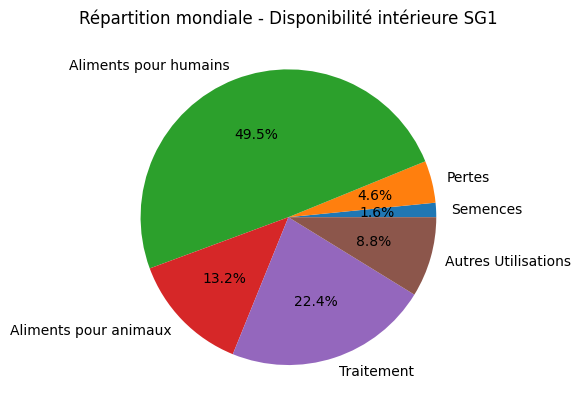

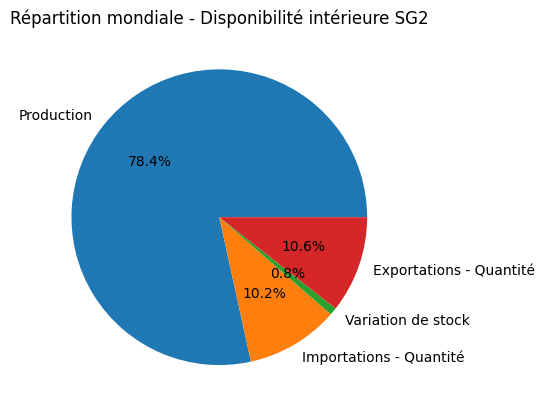

In [ ]:
#création d'une boucle for pour afficher les différentes valeurs en fonction des colonnes aliments pour animaux, pertes, nourritures,

# disponibilité alimentaire pour le sous-groupe 1 avec parcours via un for
data_disponibilite_interieure_sg1 = {}
for label, valeurs in dispo_interieure_totale_sg1.items():
  valeurs = abs(valeurs)
  data_disponibilite_interieure_sg1[label] = (valeurs / dispo_interieure_totale_sg1.sum()) * 100

data_disponibilite_interieure_sg1 = pd.DataFrame([data_disponibilite_interieure_sg1])

# Diagramme en camember est le meilleur pour montrer la répartition en pourcentage de quelques valeurs
# pour une même année
plt.pie(data_disponibilite_interieure_sg1.iloc[0],
         labels=data_disponibilite_interieure_sg1.columns,
         autopct='%1.1f%%')
plt.title('Répartition mondiale - Disponibilité intérieure SG1')
plt.show()

# disponibilité alimentaire pour le sous-groupe 2
data_disponibilite_interieure_sg2 = {}
for label, valeurs in dispo_interieure_totale_sg2.items():
  valeurs = abs(valeurs)
  data_disponibilite_interieure_sg2[label] = (valeurs / dispo_interieure_totale_sg2.sum()) * 100

data_disponibilite_interieure_sg2 = pd.DataFrame([data_disponibilite_interieure_sg2])

plt.pie(data_disponibilite_interieure_sg2.iloc[0],
         labels=data_disponibilite_interieure_sg2.columns,
         autopct='%1.1f%%')
plt.title('Répartition mondiale - Disponibilité intérieure SG2')
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.5 - Utilisation des céréales</h3>
</div>

In [ ]:
#Création d'une liste avec toutes les variables
cereales_list = ['Blé', 'Riz (Eq Blanchi)', 'Orge', 'Maïs', 'Seigle', 'Avoine', 'Millet', 'Sorgho', 'Céréales, Autres']

In [ ]:
#Création d'un dataframe avec les informations uniquement pour ces céréales
df_cereales = population_dispo_alimentaire_merge.loc[
    population_dispo_alimentaire_merge['Produit'].isin(cereales_list)
    & (population_dispo_alimentaire_merge['Année'] == 2017)]
df_cereales.head()

,Zone,Année,Population,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),...,Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Aliments pour humains,Pertes,Production,Semences,Traitement,Variation de stock,Dispo_kcal_mondial_personne_jour
247,Afghanistan,2017,36296113.0,Blé,vegetale,0.0,0.0,1369.0,160.23,4.69,...,5.992000e+09,0.0,1.173000e+09,4.895000e+09,775000000.0,5.169000e+09,322000000.0,0.0,-350000000.0,2868.797192
252,Afghanistan,2017,36296113.0,"Céréales, Autres",vegetale,0.0,0.0,0.0,0.00,0.00,...,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.0,0.0,0.0,2868.797192
272,Afghanistan,2017,36296113.0,Maïs,vegetale,200000000.0,0.0,21.0,2.50,0.30,...,3.130000e+08,0.0,1.000000e+06,7.600000e+07,31000000.0,3.120000e+08,5000000.0,0.0,0.0,2868.797192
274,Afghanistan,2017,36296113.0,Millet,vegetale,0.0,0.0,3.0,0.40,0.02,...,1.300000e+07,0.0,0.000000e+00,1.200000e+07,1000000.0,1.300000e+07,0.0,0.0,0.0,2868.797192
280,Afghanistan,2017,36296113.0,Orge,vegetale,360000000.0,0.0,26.0,2.92,0.24,...,5.240000e+08,0.0,1.000000e+07,8.900000e+07,52000000.0,5.140000e+08,22000000.0,0.0,0.0,2868.797192


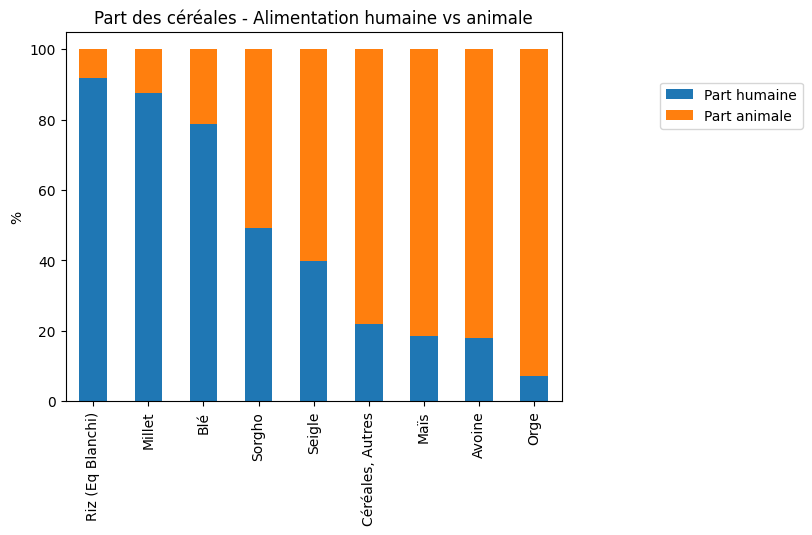

In [ ]:
# Proportion des céréales entre l'alimentation humaine et animale

# grouper par produit
df_cereales = df_cereales.groupby('Produit', as_index=False)[
    ['Aliments pour humains',
    'Aliments pour animaux']].sum()

#total par céréale
df_cereales['Total_cereales'] = df_cereales['Aliments pour humains'] + df_cereales['Aliments pour animaux']

# Calcul des pourcentages
df_cereales['Prop_humains (%)'] = round((df_cereales['Aliments pour humains']/df_cereales['Total_cereales'])*100, 2)
df_cereales['Prop_animaux (%)'] = round((df_cereales['Aliments pour animaux']/df_cereales['Total_cereales'])*100, 2)

# liste ordonnées sur les céréales les plus distribués pour les humains
df_cereales = df_cereales.sort_values('Prop_humains (%)', ascending=False)

# Création d'un graphique à barre empilée pour montrer pour chaque produit la part animale et humaine
ax = df_cereales.plot(kind='bar', x='Produit', y=['Prop_humains (%)', 'Prop_animaux (%)'], stacked=True)
ax.legend(['Part humaine', 'Part animale'], loc='right', bbox_to_anchor=(1.5, 0.8))
plt.title('Part des céréales - Alimentation humaine vs animale')
plt.xlabel('')
plt.ylabel('%')
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.6 - Pays avec la proportion de personnes sous-alimentée la plus forte en 2017</h3>
</div>

In [ ]:
#Création de la colonne proportion par pays (autre test)

# Calculer le total de kcal par habitant par pays sum(Disponibilité_kcal), groupby('Zone')
# faire un classement croissant où le plus faible pourcentage représente le pays le plus sous-alimenté
prop_kcal_quantite_pays = df_population_dispo_alimentaire_2017.groupby('Zone')['Disponibilité alimentaire (Kcal/personne/jour)'].sum().reset_index(name="Total_Kcal_hab_pays")
prop_kcal_quantite_pays['Prop_pays_sous_alimentee(%)'] = prop_kcal_quantite_pays['Total_Kcal_hab_pays'] / population_dispo_alimentaire_merge['Dispo_kcal_mondial_personne_jour']

prop_kcal_quantite_pays['Prop_pays_sous_alimentee(%)'] = round((prop_kcal_quantite_pays['Prop_pays_sous_alimentee(%)'])*100, 2)

# On merge à la dataframe originale pour de futures analyses
df_population_dispo_alimentaire_2017 = df_population_dispo_alimentaire_2017.merge(prop_kcal_quantite_pays, on='Zone')

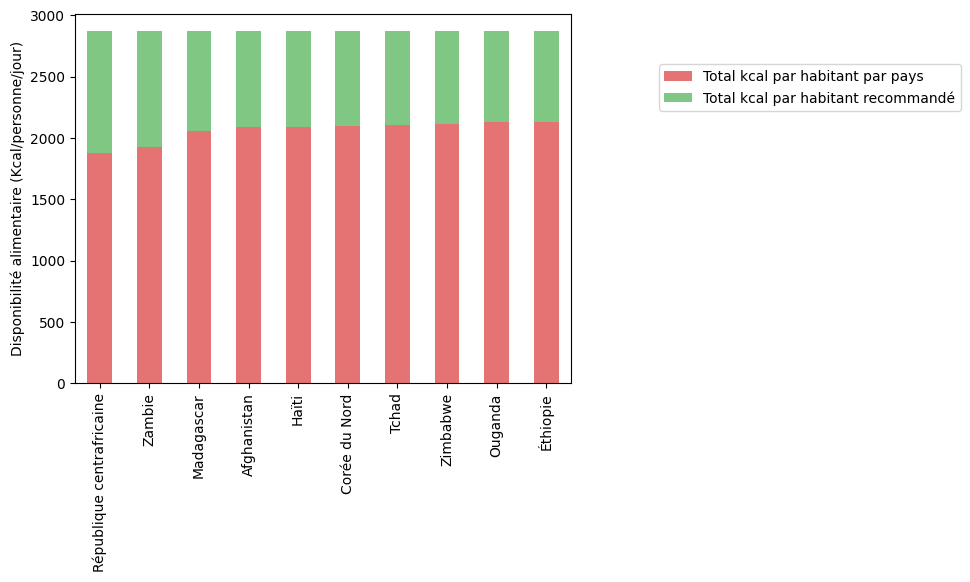

In [ ]:
#affichage après trie des 10 pires pays
# drop duplicates -> les données sont déjà aggrégés par zone dans la dataframe originale
liste_10_pire_pays = df_population_dispo_alimentaire_2017.drop_duplicates(subset=['Zone'])[
    ['Zone', 'Total_Kcal_hab_pays', 'Prop_pays_sous_alimentee(%)']
    ]
liste_10_pire_pays = liste_10_pire_pays.sort_values('Prop_pays_sous_alimentee(%)', ascending=True).head(10)
liste_10_pire_pays['Zone'] = liste_10_pire_pays['Zone'].replace({
    'République populaire démocratique de Corée': 'Corée du Nord'
})

liste_10_pire_pays['Diff_kcal_jour_hab'] = population_dispo_alimentaire_merge['Dispo_kcal_mondial_personne_jour'].iloc[0] - liste_10_pire_pays['Total_Kcal_hab_pays']

# Diagramme en barre empilée pour montrer la part calorique pour chaque pays (en rouge)
# et la différence entre la part calorique disponible mondiale et la part pour chaque pays
ax = liste_10_pire_pays.plot(x='Zone',
                             y=['Total_Kcal_hab_pays', 'Diff_kcal_jour_hab'],
                             kind='bar',
                             color=['#E57373', '#81C784'],
                             stacked=True)
plt.xticks(rotation=90)
plt.xlabel("")
plt.ylabel('Disponibilité alimentaire (Kcal/personne/jour)')
ax.legend(['Total kcal par habitant par pays', 'Total kcal par habitant recommandé'], loc='right', bbox_to_anchor=(1.8, 0.8))
plt.show()


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.7 - Pays qui ont le plus bénéficié d'aide alimentaire depuis 2013</h3>
</div>

In [ ]:
#calcul du total de l'aide alimentaire par pays
columns_zone_annee_aide = ['Zone', 'Année', 'Aide_alimentaire']
df_zone_annee_aide = aide_alimentaire.loc[(aide_alimentaire['Année'] >= 2013) & (aide_alimentaire['Année'] <= 2016),
    columns_zone_annee_aide]
total_aide_alimentaire_pays = df_zone_annee_aide.groupby('Zone')['Aide_alimentaire'].sum().reset_index()

In [ ]:
#affichage après trie des 10 pays qui ont bénéficié le plus de l'aide alimentaire
total_aide_alimentaire_pays["Montant_aide (en T de produits)"] = total_aide_alimentaire_pays['Aide_alimentaire']

total_aide_alimentaire_pays["Montant_aide (en milliards de T de produits)"] = round(total_aide_alimentaire_pays["Montant_aide (en T de produits)"]/1000000000, 2)
total_aide_alimentaire_10pays = total_aide_alimentaire_pays.sort_values("Montant_aide (en milliards de T de produits)", ascending=False).head(10)
total_aide_alimentaire_10pays = total_aide_alimentaire_10pays.loc[:, ['Zone', 'Montant_aide (en milliards de T de produits)']]
total_aide_alimentaire_10pays.head(10)

,Zone,Montant_aide (en milliards de T de produits)
50,République arabe syrienne,1.86
75,Éthiopie,1.38
70,Yémen,1.21
61,Soudan du Sud,0.70
60,Soudan,0.67
30,Kenya,0.55
3,Bangladesh,0.35
53,République démocratique du Congo,0.29
59,Somalie,0.29
43,Niger,0.28


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.8 - Evolution des 5 pays qui ont le plus bénéficiés de l'aide alimentaire entre 2013 et 2016</h3>
</div>

In [ ]:
#Création d'un dataframe avec la zone, l'année et l'aide alimentaire puis groupby sur zone et année
grouped_zone_annee_aide = df_zone_annee_aide.groupby(['Zone', 'Année']).agg('sum').reset_index()

In [ ]:
#Création d'une liste contenant les 5 pays qui ont le plus bénéficiées de l'aide alimentaire
df_grouped_5_countries_aide = grouped_zone_annee_aide.groupby(['Zone'])['Aide_alimentaire'].agg('sum').sort_values(ascending=False).head(5).reset_index()
list_5_top_pays_aide = df_grouped_5_countries_aide['Zone']
print(list_5_top_pays_aide)

0    République arabe syrienne
1                     Éthiopie
2                        Yémen
3                Soudan du Sud
4                       Soudan
Name: Zone, dtype: object


In [ ]:
#On filtre sur le dataframe avec notre liste
df_top_5_pays_aide = df_zone_annee_aide.loc[df_zone_annee_aide['Zone'].isin(list_5_top_pays_aide), ['Zone', 'Année', 'Aide_alimentaire']]

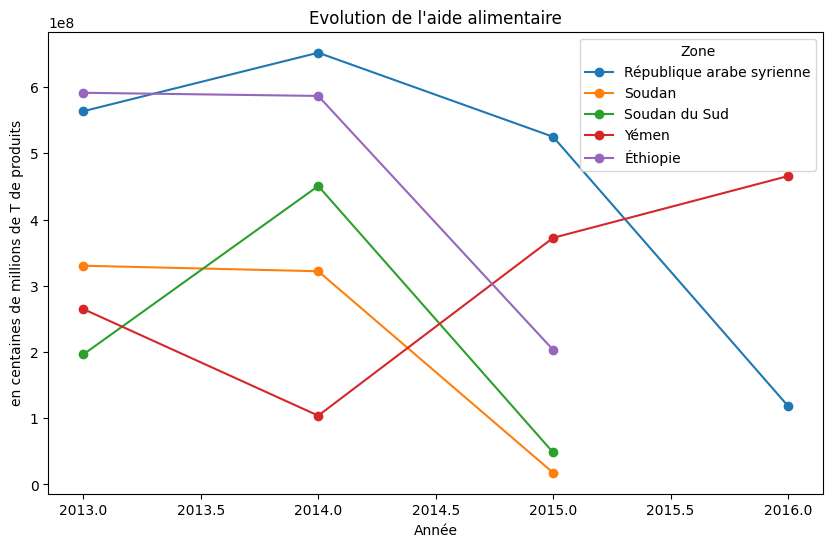

In [ ]:
# Affichage des pays avec l'aide alimentaire par année
df_top_5_pays_aide = df_top_5_pays_aide.groupby(['Zone', 'Année'])['Aide_alimentaire'].sum().reset_index()
# Création d'une table pivot avec en abscisse les années, en ordonnée les pays et en
df_top_5_pays_aide_pt = df_top_5_pays_aide.pivot_table(index='Zone', columns='Année', values='Aide_alimentaire')

# Avec le .T, je peux inverser la légende et l'abscisse
df_top_5_pays_aide_pt.T.plot(marker='o', figsize=(10,6))
plt.ylabel('en centaines de millions de T de produits')
plt.title("Evolution de l'aide alimentaire")
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.9 - Pays avec le moins de disponibilité par habitant</h3>
</div>

In [ ]:
#Calcul de la disponibilité en kcal par personne par jour par pays
# On additionne toutes les kcal pour chaque produit
disponibilite_personne_jour_pays = dispo_alimentaire.groupby('Zone')['Disponibilité alimentaire (Kcal/personne/jour)'].agg('sum').reset_index()
disponibilite_personne_jour_pays.head()

,Zone,Disponibilité alimentaire (Kcal/personne/jour)
0,Afghanistan,2087.0
1,Afrique du Sud,3020.0
2,Albanie,3188.0
3,Algérie,3293.0
4,Allemagne,3503.0


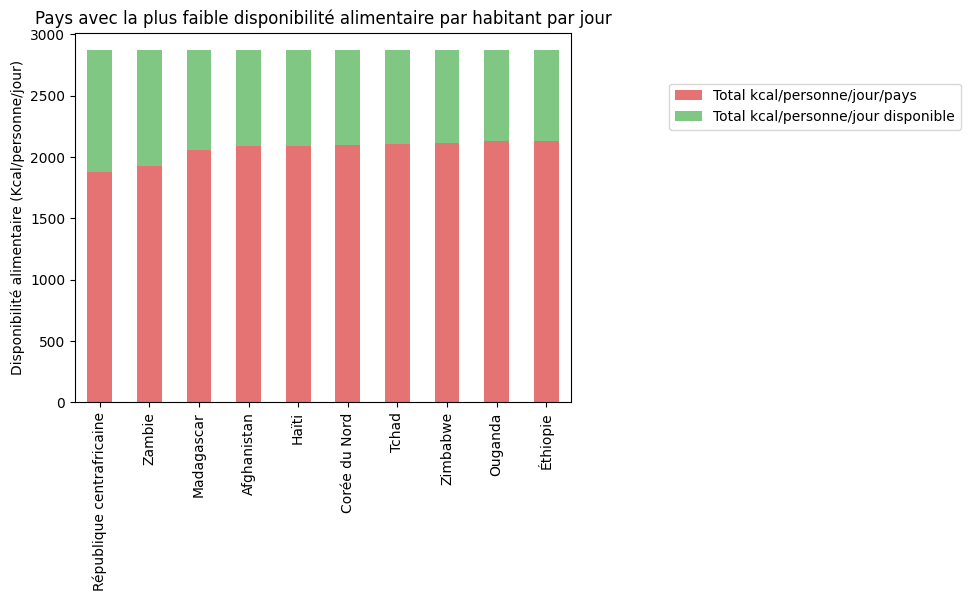

,Zone,Disponibilité alimentaire (Kcal/personne/jour),Diff_kcal
128,République centrafricaine,1879.0,989.797192
166,Zambie,1924.0,944.797192
91,Madagascar,2056.0,812.797192
0,Afghanistan,2087.0,781.797192
65,Haïti,2089.0,779.797192
133,Corée du Nord,2093.0,775.797192
151,Tchad,2109.0,759.797192
167,Zimbabwe,2113.0,755.797192
114,Ouganda,2126.0,742.797192
172,Éthiopie,2129.0,739.797192


In [ ]:
#Affichage des 10 pays qui ont le moins de dispo alimentaire par personne
bottom_10_pays_dispo_alimentaire_personne = disponibilite_personne_jour_pays.sort_values('Disponibilité alimentaire (Kcal/personne/jour)', ascending=True).head(10)
bottom_10_pays_dispo_alimentaire_personne['Diff_kcal'] = population_dispo_alimentaire_merge['Dispo_kcal_mondial_personne_jour'].iloc[0] - bottom_10_pays_dispo_alimentaire_personne['Disponibilité alimentaire (Kcal/personne/jour)']
bottom_10_pays_dispo_alimentaire_personne['Zone'] = bottom_10_pays_dispo_alimentaire_personne['Zone'].replace({
    'République populaire démocratique de Corée': 'Corée du Nord'
})
ax = bottom_10_pays_dispo_alimentaire_personne.plot(kind='bar',
                                                   x='Zone',
                                                   y=['Disponibilité alimentaire (Kcal/personne/jour)', 'Diff_kcal'],
                                                    color=['#E57373', '#81C784'],
                                                   stacked=True)
plt.title('Pays avec la plus faible disponibilité alimentaire par habitant par jour')
plt.ylabel('Disponibilité alimentaire (Kcal/personne/jour)')
ax.legend(['Total kcal/personne/jour/pays', 'Total kcal/personne/jour disponible'], loc='right', bbox_to_anchor=(1.8, 0.8))
plt.xlabel('')
plt.show()
bottom_10_pays_dispo_alimentaire_personne.head(10)

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.10 - Pays avec le plus de disponibilité par habitant</h3>
</div>

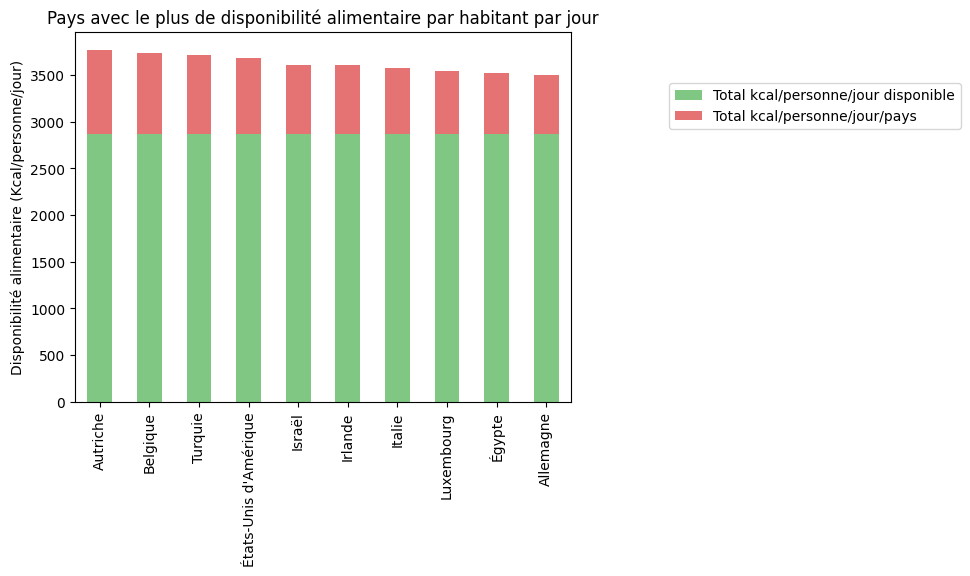

,Zone,Disponibilité alimentaire (Kcal/personne/jour),kcal_moyenne,Diff_kcal
11,Autriche,3770.0,2868.797192,901.202808
16,Belgique,3737.0,2868.797192,868.202808
159,Turquie,3708.0,2868.797192,839.202808
171,États-Unis d'Amérique,3682.0,2868.797192,813.202808
74,Israël,3610.0,2868.797192,741.202808
72,Irlande,3602.0,2868.797192,733.202808
75,Italie,3578.0,2868.797192,709.202808
89,Luxembourg,3540.0,2868.797192,671.202808
168,Égypte,3518.0,2868.797192,649.202808
4,Allemagne,3503.0,2868.797192,634.202808


In [ ]:
#Affichage des 10 pays qui ont le plus de dispo alimentaire par personne
top_10_pays_dispo_alimentaire_personne = disponibilite_personne_jour_pays.sort_values('Disponibilité alimentaire (Kcal/personne/jour)', ascending=False).head(10)

# Création d'un bar plot pour montrer la différence
top_10_pays_dispo_alimentaire_personne['kcal_moyenne'] = population_dispo_alimentaire_merge['Dispo_kcal_mondial_personne_jour'].iloc[0]
top_10_pays_dispo_alimentaire_personne['Diff_kcal'] = top_10_pays_dispo_alimentaire_personne['Disponibilité alimentaire (Kcal/personne/jour)'] - top_10_pays_dispo_alimentaire_personne['kcal_moyenne'].iloc[0]

# Même remarque que pour le premier graphique du même style sauf que la partie en vert représente la part disponible
# chaque habitant au niveau mondial et la partie en rouge le surplus calorique
ax = top_10_pays_dispo_alimentaire_personne.plot(kind='bar',
                                                   x='Zone',
                                                   y=['kcal_moyenne', 'Diff_kcal'],
                                                   stacked=True,
                                                color=['#81C784', '#E57373'])
plt.title('Pays avec le plus de disponibilité alimentaire par habitant par jour')
plt.ylabel('Disponibilité alimentaire (Kcal/personne/jour)')
ax.legend(['Total kcal/personne/jour disponible', 'Total kcal/personne/jour/pays'], loc='right', bbox_to_anchor=(1.8, 0.8))
plt.xlabel('')
plt.show()
top_10_pays_dispo_alimentaire_personne.head(10)

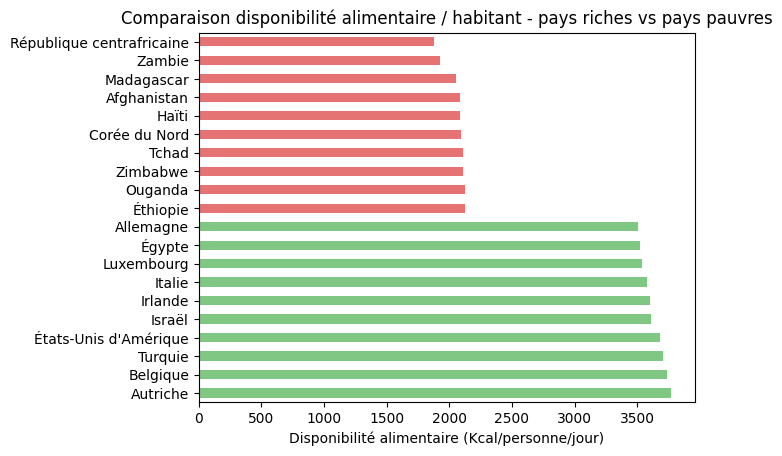

In [ ]:
comparaison_bottom_top_pays_disponibilite = pd.concat([top_10_pays_dispo_alimentaire_personne,bottom_10_pays_dispo_alimentaire_personne])
comparaison_bottom_top_pays_disponibilite_srt = comparaison_bottom_top_pays_disponibilite.sort_values('Disponibilité alimentaire (Kcal/personne/jour)', ascending=False)
comparaison_bottom_top_pays_disponibilite_srt.plot(kind='barh',
                                                   x='Zone',
                                                   y='Disponibilité alimentaire (Kcal/personne/jour)',
                                                   legend=False,
                                                  color=['#81C784' if x in top_10_pays_dispo_alimentaire_personne['Zone'].values else '#E57373' for x in comparaison_bottom_top_pays_disponibilite_srt['Zone']])
plt.title('Comparaison disponibilité alimentaire / habitant - pays riches vs pays pauvres')
plt.xlabel('Disponibilité alimentaire (Kcal/personne/jour)')
plt.ylabel('')
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.11 - Exemple de la Thaïlande pour le Manioc</h3>
</div>

In [ ]:
#création d'un dataframe avec uniquement la Thaïlande
df_thailande = pd.merge(population_sous_nutrition_merge, dispo_alimentaire, on='Zone')
df_thailande = df_thailande.loc[df_thailande['Zone'] == 'Thaïlande']
df_thailande.head()

,Zone,Année_population,Population,Année_sous_nutrition,Sous_nutrition,Année médian,Produit,Origine,Aliments pour animaux,Autres Utilisations,...,Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Aliments pour humains,Pertes,Production,Semences,Traitement,Variation de stock
508176,Thaïlande,2013,68144518.0,2012-2014,6200000.0,2013,Abats Comestible,animale,0.0,0.0,...,0.56,74000000.0,5.000000e+06,33000000.0,75000000.0,0.0,4.500000e+07,0.0,0.0,0.0
508177,Thaïlande,2013,68144518.0,2012-2014,6200000.0,2013,"Agrumes, Autres",vegetale,0.0,0.0,...,0.00,8000000.0,6.000000e+06,2000000.0,6000000.0,0.0,1.200000e+07,0.0,2000000.0,0.0
508178,Thaïlande,2013,68144518.0,2012-2014,6200000.0,2013,"Alcool, non Comestible",vegetale,0.0,358000000.0,...,0.00,358000000.0,1.100000e+08,21000000.0,0.0,0.0,4.470000e+08,0.0,0.0,0.0
508179,Thaïlande,2013,68144518.0,2012-2014,6200000.0,2013,Aliments pour enfants,vegetale,0.0,0.0,...,0.08,12000000.0,7.000000e+06,19000000.0,12000000.0,0.0,0.000000e+00,0.0,0.0,0.0
508180,Thaïlande,2013,68144518.0,2012-2014,6200000.0,2013,Ananas,vegetale,0.0,0.0,...,0.08,782000000.0,1.449000e+09,9000000.0,671000000.0,110000000.0,2.209000e+09,0.0,0.0,13000000.0


In [ ]:
# On calcule la proportion exportée en fonction de la production
df_thailande_manioc_2017 = df_thailande[(df_thailande['Année_population'] == 2017) &
                                   (df_thailande['Produit'] == 'Manioc')]

# On prend uniquement la première ligne car toutes les lignes sont les mêmes
# Mais on ne peut pas supprimer les éléments dupliqués à cause du merge avec
# la dataframe sous-nutrition
df_thailande_manioc_2017 = df_thailande_manioc_2017.head(1)

total_exportations_manioc_thailande = df_thailande_manioc_2017['Exportations - Quantité'].iloc[0]
total_production_manioc_thailande = df_thailande_manioc_2017['Production'].iloc[0]

proportion_export_manioc_total = total_exportations_manioc_thailande / total_production_manioc_thailande

print('Part de manioc exportée en Thailande : {}%'.format(round(proportion_export_manioc_total*100, 2)))

Part de manioc exportée en Thailande : 83.41%


In [ ]:
# Calcul de la sous nutrition en Thaïlande

# moyenne de personnes en sous-nutrition / moyenne de la population
groupe_mean_pop_sous_nutrition = df_thailande_manioc_2017.groupby('Zone')[['Population', 'Sous_nutrition']].mean()

part_sous_nutrition_thailande = groupe_mean_pop_sous_nutrition['Sous_nutrition'] / groupe_mean_pop_sous_nutrition['Population']

print('Part de la population en sous-nutrition en Thailande : {}%'.format(round(part_sous_nutrition_thailande.iloc[0]*100, 2)))

Part de la population en sous-nutrition en Thailande : 8.96%


In [ ]:
# Calcul de la disponibilité du manioc par habitant pour la thailande
# disponbilité pour le manioc divisé par la population totale

# On récupère le champs d'un autre calcul et on le renomme pour éviter de confondre
pop_thailande = df_thailande_manioc_2017['Population'].iloc[0]

# On converti la valeur en kg pour avoir les deux valeurs au plus près de la réalité
dispo_manioc_totale = df_thailande_manioc_2017['Aliments pour humains'].iloc[0]

# dispo total alimentation humaine / Population totale
rapport_disponbilite_interieur_habitant = dispo_manioc_totale / pop_thailande
print('Part du manioc disponible par habitant en Thailande : {}kg'.format(round(rapport_disponbilite_interieur_habitant,0)))

Part du manioc disponible par habitant en Thailande : 13.0kg


<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 6 - Analyse complémentaires</h2>
</div>

In [ ]:
#ajouter en dessous toutes les analyses complémentaires

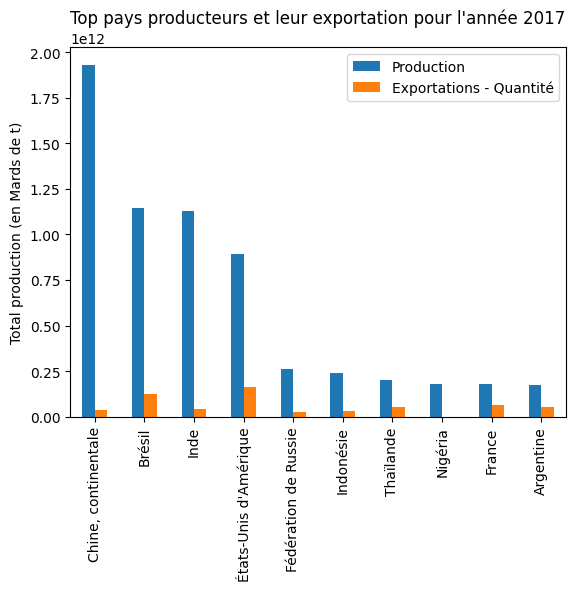

In [ ]:
# Liste des 10 pays qui produisent le plus et la répartition de leur production
dispo_alimentaire_cp = dispo_alimentaire.copy()
productions_par_pays = dispo_alimentaire_cp.groupby('Zone')[['Production', 'Exportations - Quantité']].sum()
liste_10_pays_producteurs = productions_par_pays.sort_values(by="Production", ascending=False).head(10)
liste_10_pays_producteurs.plot(kind='bar')
plt.title('Top pays producteurs et leur exportation pour l\'année 2017')
plt.xlabel('')
plt.ylabel('Total production (en Mards de t)')
plt.show()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7308 entries, 0 to 7307
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Zone                  7308 non-null   object 
 1   Année_population      7308 non-null   int64  
 2   Population            7308 non-null   float64
 3   Année_sous_nutrition  7308 non-null   object 
 4   Sous_nutrition        7308 non-null   float64
 5   Année médian          7308 non-null   int64  
dtypes: float64(2), int64(2), object(2)
memory usage: 342.7+ KB


/tmp/ipython-input-2044460212.py:20: UserWarning: 
The markers list has fewer values (1) than needed (5) and will cycle, which may produce an uninterpretable plot.
  ax = sns.relplot(data=pays_sous_nutrition_annee,
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)


Text(59.187921296296295, 0.5, 'Proportion de personnes en sous nutrition')

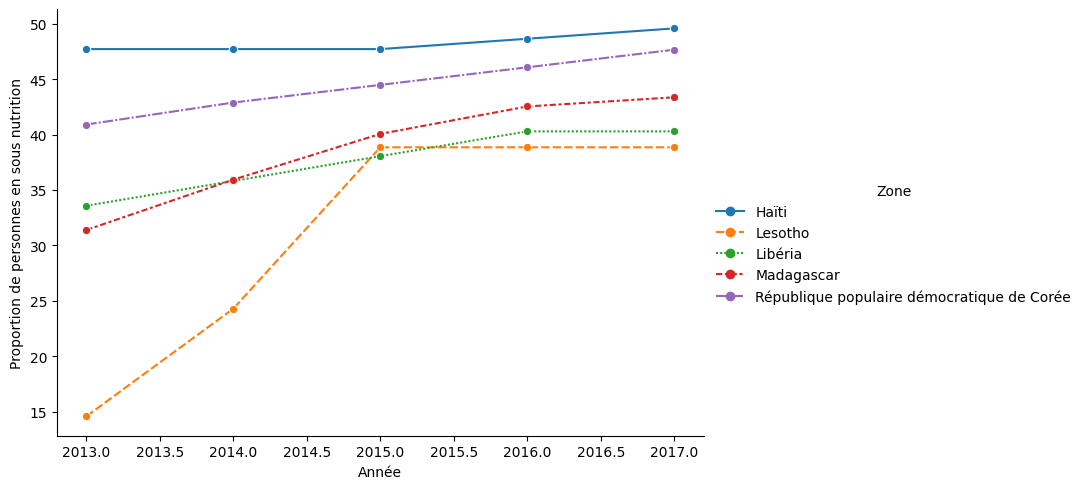

In [ ]:
# Evolution de la proportion de personnes en sous-nutrition de 2013 à 2017 pour les 5 pays qui ont eu en 2017 la plus élévée
population_sous_nutrition_merge.info()
liste_pays_sous_nutrition = top_10_pays_prop_sous_nutri_2017['Zone'].head(5)
df_pays_sous_nutrition = population_sous_nutrition_merge[
    (population_sous_nutrition_merge['Zone'].isin(liste_pays_sous_nutrition)) &
    (
        (population_sous_nutrition_merge['Année_population'] >= 2013) &
        (population_sous_nutrition_merge['Année_population'] <= 2017)
    )
    &
    (
        (population_sous_nutrition_merge['Année médian'] >= 2013) &
        (population_sous_nutrition_merge['Année médian'] <= 2017)
    )
    ]
# groupby année sous nutrition
pays_sous_nutrition_annee = df_pays_sous_nutrition.groupby(['Zone','Année_population', 'Année médian'])[['Sous_nutrition', 'Population']].sum().reset_index()
pays_sous_nutrition_annee['Proportion_sous_nutrition'] = round((pays_sous_nutrition_annee['Sous_nutrition'] / pays_sous_nutrition_annee['Population'])*100, 2)

ax = sns.relplot(data=pays_sous_nutrition_annee,
                  x='Année médian',
                  y='Proportion_sous_nutrition',
                  hue='Zone',
                 kind='line',
                markers='o',
                 style='Zone',
                 aspect=1.5,
                 ci=None)
plt.xlabel('Année')
plt.ylabel('Proportion de personnes en sous nutrition')